# 1. Configuración de Kaggle

In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


# 2. Descarga de datos

In [ ]:
!kaggle competitions download -c favorita-grocery-sales-forecasting
!ls

100% 458M/458M [00:05<00:00, 81.7MB/s]

 favorita-grocery-sales-forecasting.zip   kaggle.json
'kaggle (1).json'			  sample_data


In [ ]:
!unzip -o favorita-grocery-sales-forecasting.zip

Archive:  favorita-grocery-sales-forecasting.zip
  inflating: holidays_events.csv.7z  
  inflating: items.csv.7z            
  inflating: oil.csv.7z              
  inflating: sample_submission.csv.7z  
  inflating: stores.csv.7z           
  inflating: test.csv.7z             
  inflating: train.csv.7z            
  inflating: transactions.csv.7z     


In [ ]:
!ls -la

total 937448
drwxr-xr-x 1 root root      4096 Aug  3 23:44  .
drwxr-xr-x 1 root root      4096 Aug  3 23:02  ..
drwxr-xr-x 4 root root      4096 Jun  4 13:32  .config
-rw-r--r-- 1 root root 480014675 Dec 11  2019  favorita-grocery-sales-forecasting.zip
-rw-r--r-- 1 root root      1898 Dec 11  2019  holidays_events.csv.7z
-rw-r--r-- 1 root root     14315 Dec 11  2019  items.csv.7z
-rw-r--r-- 1 root root        73 Aug  3 23:37 'kaggle (1).json'
-rw-r--r-- 1 root root        73 Aug  3 23:07  kaggle.json
-rw-r--r-- 1 root root      3762 Dec 11  2019  oil.csv.7z
drwxr-xr-x 1 root root      4096 Jun  4 13:32  sample_data
-rw-r--r-- 1 root root    666528 Dec 11  2019  sample_submission.csv.7z
-rw-r--r-- 1 root root       648 Dec 11  2019  stores.csv.7z
-rw-r--r-- 1 root root   4885065 Dec 11  2019  test.csv.7z
-rw-r--r-- 1 root root 474092593 Dec 11  2019  train.csv.7z
-rw-r--r-- 1 root root    219499 Dec 11  2019  transactions.csv.7z


In [ ]:
# Descomprimir
!apt-get install -y p7zip-full -q

Reading package lists...
Building dependency tree...
Reading state information...
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
!7z x train.csv.7z -y
!7z x stores.csv.7z -y
!7z x items.csv.7z -y
!7z x oil.csv.7z -y
!7z x holidays_events.csv.7z -y
!7z x transactions.csv.7z -y


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 474092593 bytes (453 MiB)

Extracting archive: train.csv.7z
--
Path = train.csv.7z
Type = 7z
Physical Size = 474092593
Headers Size = 122
Method = LZMA2:24
Solid = -
Blocks = 1

  0%      0% - train.csv                  1% - train.csv                  2% - train.csv                  3% - train.csv                  4% - train.csv                  5% - train.csv                  6% - train.csv                  7% - train.csv                  8% - train.csv

In [ ]:
!ls -la

total 5819452
drwxr-xr-x 1 root root       4096 Aug  3 23:52  .
drwxr-xr-x 1 root root       4096 Aug  3 23:02  ..
drwxr-xr-x 4 root root       4096 Jun  4 13:32  .config
-rw-r--r-- 1 root root  480014675 Dec 11  2019  favorita-grocery-sales-forecasting.zip
-rw-r--r-- 1 root root      22309 Oct 19  2017  holidays_events.csv
-rw-r--r-- 1 root root       1898 Dec 11  2019  holidays_events.csv.7z
-rw-r--r-- 1 root root     101841 Oct 19  2017  items.csv
-rw-r--r-- 1 root root      14315 Dec 11  2019  items.csv.7z
-rw-r--r-- 1 root root         73 Aug  3 23:37 'kaggle (1).json'
-rw-r--r-- 1 root root         73 Aug  3 23:07  kaggle.json
-rw-r--r-- 1 root root      20580 Oct 19  2017  oil.csv
-rw-r--r-- 1 root root       3762 Dec 11  2019  oil.csv.7z
drwxr-xr-x 1 root root       4096 Jun  4 13:32  sample_data
-rw-r--r-- 1 root root     666528 Dec 11  2019  sample_submission.csv.7z
-rw-r--r-- 1 root root       1387 Oct 19  2017  stores.csv
-rw-r--r-- 1 root root        648 Dec 11  2019  stor

In [ ]:
#Tiendas disponibles
import pandas as pd

stores = pd.read_csv('stores.csv')
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [ ]:
stores['state'].value_counts()

,count
state,
Pichincha,19
Guayas,11
Azuay,3
Santo Domingo de los Tsachilas,3
Manabi,3
Los Rios,2
Cotopaxi,2
Tungurahua,2
El Oro,2


In [ ]:
#Familias de productos disponibles
items = pd.read_csv('items.csv')
items['family'].value_counts()

,count
family,
GROCERY I,1334
BEVERAGES,613
CLEANING,446
PRODUCE,306
DAIRY,242
PERSONAL CARE,153
BREAD/BAKERY,134
HOME CARE,108
DELI,91


# 3. Filtrar datos

In [ ]:
tiendas = stores.loc[stores['state'] == 'Pichincha', 'store_nbr'].tolist()
productos = items.loc[items['family'] == 'DAIRY', 'item_nbr'].tolist()

print(len(tiendas), 'tiendas')
print(len(productos), 'productos')

19 tiendas
242 productos


In [ ]:
#Filtro en chunks por falta de memoria
chunks_filtrados = []

for chunk in pd.read_csv(
    'train.csv',
    chunksize=2_000_000,
    dtype={'store_nbr': 'int32', 'item_nbr': 'int32', 'unit_sales': 'float32', 'onpromotion': 'object'},
    parse_dates=['date']
):
    filtrado = chunk[chunk['store_nbr'].isin(tiendas) & chunk['item_nbr'].isin(productos)]
    chunks_filtrados.append(filtrado)

train_filtrado = pd.concat(chunks_filtrados, ignore_index=True)
train_filtrado.shape

(4025458, 6)

In [ ]:
# Unión de tablas
oil = pd.read_csv('oil.csv', parse_dates=['date'])
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])

df = train_filtrado.merge(stores, on='store_nbr', how='left')
df = df.merge(items, on='item_nbr', how='left')
df = df.merge(oil, on='date', how='left')
df = df.merge(holidays, on='date', how='left', suffixes=('', '_holiday'))

df.shape
df.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,city,state,type,cluster,family,class,perishable,dcoilwtico,type_holiday,locale,locale_name,description,transferred
0,618,2013-01-02,1,122095,1.0,NaN,Quito,Pichincha,D,13,DAIRY,2124,1,93.14,NaN,NaN,NaN,NaN,NaN
1,621,2013-01-02,1,123347,3.0,NaN,Quito,Pichincha,D,13,DAIRY,2114,1,93.14,NaN,NaN,NaN,NaN,NaN
2,628,2013-01-02,1,129635,29.0,NaN,Quito,Pichincha,D,13,DAIRY,2112,1,93.14,NaN,NaN,NaN,NaN,NaN
3,640,2013-01-02,1,158842,1.0,NaN,Quito,Pichincha,D,13,DAIRY,2124,1,93.14,NaN,NaN,NaN,NaN,NaN
4,647,2013-01-02,1,164088,6.0,NaN,Quito,Pichincha,D,13,DAIRY,2116,1,93.14,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Guardar resultados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/TFM', exist_ok=True)

df.to_parquet('/content/drive/MyDrive/TFM/favorita_filtrado.parquet')

In [ ]:
prueba = pd.read_parquet('/content/drive/MyDrive/TFM/favorita_filtrado.parquet')
prueba.shape

(4102969, 19)

In [ ]:
# Revisión de fechas y celdas vacías
print(df['date'].min(), df['date'].max())
df.isnull().sum()

2013-01-02 00:00:00 2017-08-15 00:00:00


,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,682293
city,0
state,0
type,0
cluster,0


In [ ]:
# Revisar valores negativos en ventas
(df['unit_sales'] < 0).sum()

np.int64(194)

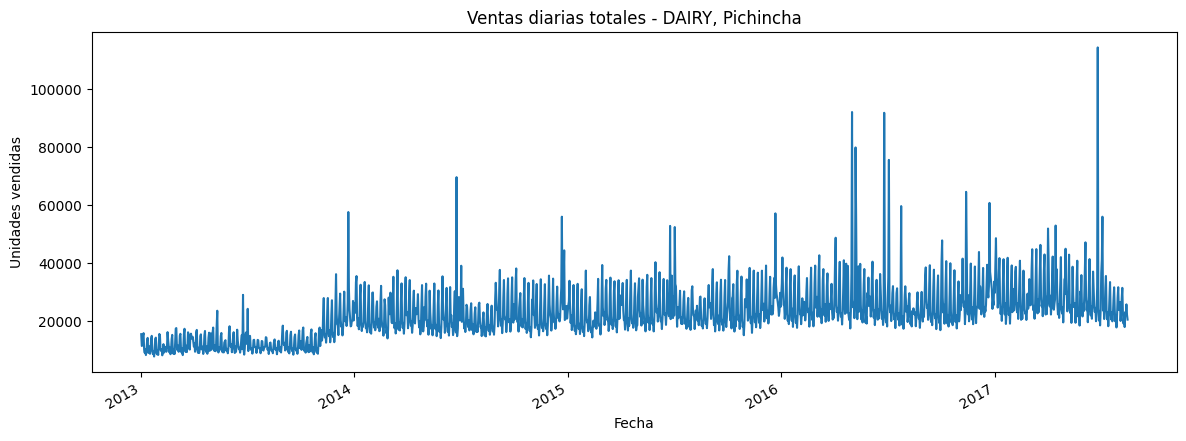

In [ ]:
# Gráficas para revisión
import matplotlib.pyplot as plt

ventas_diarias = df.groupby('date')['unit_sales'].sum()

plt.figure(figsize=(14, 5))
ventas_diarias.plot()
plt.title('Ventas diarias totales - DAIRY, Pichincha')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.show()